In [1]:
from pathlib import Path
import sys


sys.path.append(str(Path().resolve().parent))


                           

                                                            
                                            

BASE_DIR = Path().resolve()
PROJECT_ROOT = BASE_DIR.parent   #to go un up the the root
DATA_DIR = PROJECT_ROOT / "data"

# Root directory of dataset
root = Path(DATA_DIR)

In [2]:
import pandas as pd

def build_df(root):

    label_map = {
        1: "correct",
        2: "fast",
        3: "low_amplitude"
    }

    dfs = []   # store all partial dataframes

    for subject_dir in root.glob("s*"):
        for exercise_dir in subject_dir.glob("e*"):
            for unit_dir in exercise_dir.glob("u*"):

                file_path = unit_dir / "test.txt"

                df = pd.read_csv(file_path, sep=";")

                df["subject"] = subject_dir.name
                df["exercise"] = exercise_dir.name
                df["unit"] = unit_dir.name

                

                label_map = {
                    0: "correct",
                    1: "fast",
                    2: "low_amplitude"
                }

                segment_length = len(df) // 30

                df["execution_type"] = None

                for i in range(30):
                    start = i * segment_length
                    end = (i + 1) * segment_length

                    label_group = i // 10
                    label = label_map[label_group]

                    df.loc[start:end, "execution_type"] = label

                dfs.append(df)   # collect dataframe

    final_df = pd.concat(dfs, ignore_index=True)

    return final_df

In [3]:
df=build_df(root)


In [4]:
df[(df['subject']=='s1') & (df['exercise']=='e1') ]

,time index,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,mag_x,mag_y,mag_z,subject,exercise,unit,execution_type
0,1,-9.685645,-1.645149,0.505022,-0.020696,0.009202,-0.008566,0.589728,0.453403,-0.075234,s1,e1,u1,correct
1,2,-9.648184,-1.645353,0.513125,-0.008165,-0.001407,-0.003256,0.587024,0.453644,-0.075593,s1,e1,u1,correct
2,3,-9.700570,-1.615223,0.512321,-0.004447,0.011059,-0.008589,0.589691,0.454598,-0.075525,s1,e1,u1,correct
3,4,-9.685627,-1.630183,0.497591,-0.026110,0.009183,-0.008554,0.589240,0.452864,-0.074705,s1,e1,u1,correct
4,5,-9.655697,-1.630194,0.460742,-0.008109,0.001231,-0.005950,0.589647,0.452882,-0.076429,s1,e1,u1,correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29740,5945,-4.223868,-7.541800,-4.607269,-0.016858,-0.001904,-0.011902,0.003246,0.725318,0.231512,s1,e1,u5,None
29741,5946,-4.253123,-7.531929,-4.612775,-0.006980,-0.021866,-0.013705,0.005410,0.724710,0.231259,s1,e1,u5,None
29742,5947,-4.233624,-7.536894,-4.607502,-0.013551,-0.001552,0.000465,0.004094,0.725666,0.233084,s1,e1,u5,None
29743,5948,-4.228771,-7.517463,-4.622438,-0.020245,-0.013049,-0.019876,0.004089,0.724876,0.232979,s1,e1,u5,None


In [5]:
merged_df = df.pivot(
    index=["subject", "exercise", "time index"],
    columns="unit",
    values=["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z", "mag_x", "mag_y", "mag_z"]
)

merged_df.columns = [f"{sensor}_{unit}" for sensor, unit in merged_df.columns]
merged_df = merged_df.reset_index()




In [6]:
subject2ex1=merged_df[(merged_df['subject']=='s2') & (merged_df['exercise']=='e1') ]

In [7]:
merged_df[(merged_df['subject']=='s2') & (merged_df['exercise']=='e1') ]

,subject,exercise,time index,acc_x_u1,acc_x_u2,acc_x_u3,acc_x_u4,acc_x_u5,acc_y_u1,acc_y_u2,...,mag_y_u1,mag_y_u2,mag_y_u3,mag_y_u4,mag_y_u5,mag_z_u1,mag_z_u2,mag_z_u3,mag_z_u4,mag_z_u5
47395,s2,e1,1,-9.165251,-9.354128,-3.133053,9.630713,-0.918533,-3.503719,2.716404,...,0.593288,-0.586733,-0.832394,-0.014339,0.726868,-0.004205,0.119568,-0.132099,-0.388943,0.067230
47396,s2,e1,2,-9.157786,-9.383859,-3.157320,9.645431,-0.889263,-3.503650,2.738842,...,0.592865,-0.587147,-0.833553,-0.014761,0.725414,-0.004119,0.120250,-0.130004,-0.387961,0.068153
47397,s2,e1,3,-9.150346,-9.354235,-3.158404,9.645355,-0.913655,-3.526046,2.708877,...,0.591950,-0.585406,-0.832063,-0.016308,0.725960,-0.005679,0.119443,-0.133136,-0.389654,0.066588
47398,s2,e1,4,-9.150276,-9.376613,-3.149357,9.655215,-0.903936,-3.488718,2.709028,...,0.591661,-0.586294,-0.832856,-0.015652,0.726475,-0.004895,0.118302,-0.133613,-0.389251,0.065446
47399,s2,e1,5,-9.150281,-9.369093,-3.150248,9.640584,-0.911201,-3.503738,2.723786,...,0.592334,-0.584609,-0.831742,-0.015512,0.726846,-0.004777,0.119437,-0.131594,-0.389357,0.067388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52916,s2,e1,5522,-9.122513,-9.340549,-3.323984,9.543937,-0.782733,-3.506406,2.419840,...,0.595553,-0.573785,-0.811704,0.004905,0.720193,0.015993,0.101730,-0.142069,-0.445189,0.072927
52917,s2,e1,5523,-9.115043,-9.407550,-3.352264,9.368688,-0.746158,-3.551476,2.413148,...,0.594488,-0.574565,-0.813481,0.001469,0.718115,0.015226,0.101173,-0.144210,-0.446542,0.074450
52918,s2,e1,5524,-9.137488,-9.384971,-3.335698,9.395393,-0.719264,-3.566520,2.413322,...,0.594067,-0.574390,-0.812523,-0.002690,0.718626,0.016863,0.099028,-0.143180,-0.445703,0.075870
52919,s2,e1,5525,-9.137478,-9.414909,-3.337959,9.480650,-0.729007,-3.544003,2.450136,...,0.594186,-0.571851,-0.814080,-0.006466,0.718245,0.017508,0.098468,-0.144826,-0.443993,0.076879


In [8]:
import matplotlib.pyplot as plt

#### accelerometer magnitude of exercise 2 for subject 2 of one sensor unit

C:\Users\aless\AppData\Local\Temp\ipykernel_22536\4156647819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subject2ex1["acc_mag_u1"] = np.sqrt(
C:\Users\aless\AppData\Local\Temp\ipykernel_22536\4156647819.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subject2ex1["acc_mag_u2"] = np.sqrt(
C:\Users\aless\AppData\Local\Temp\ipykernel_22536\4156647819.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

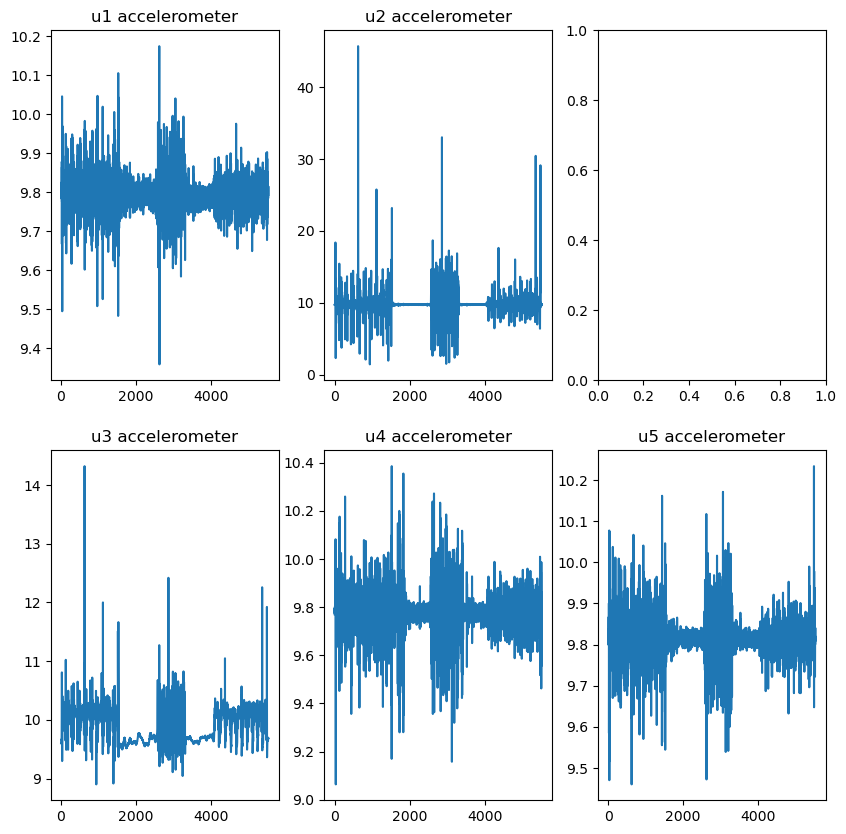

In [9]:
import numpy as np

subject2ex1["acc_mag_u1"] = np.sqrt(      
    subject2ex1["acc_x_u1"]**2 +
    subject2ex1["acc_y_u1"]**2 +
    subject2ex1["acc_z_u1"]**2
)

subject2ex1["acc_mag_u2"] = np.sqrt(      
    subject2ex1["acc_x_u2"]**2 +
    subject2ex1["acc_y_u2"]**2 +
    subject2ex1["acc_z_u2"]**2
)

subject2ex1["acc_mag_u3"] = np.sqrt(      
    subject2ex1["acc_x_u3"]**2 +
    subject2ex1["acc_y_u3"]**2 +
    subject2ex1["acc_z_u3"]**2
)

subject2ex1["acc_mag_u4"] = np.sqrt(      
    subject2ex1["acc_x_u4"]**2 +
    subject2ex1["acc_y_u4"]**2 +
    subject2ex1["acc_z_u4"]**2
)

subject2ex1["acc_mag_u5"] = np.sqrt(      
    subject2ex1["acc_x_u5"]**2 +
    subject2ex1["acc_y_u5"]**2 +
    subject2ex1["acc_z_u5"]**2
)



fig, axes= plt.subplots(ncols=3, nrows=2, figsize=(10,10))
axes[0,0].plot(subject2ex1["time index"], subject2ex1["acc_mag_u1"])
axes[0,0].set_title('u1 accelerometer')

axes[0,1].plot(subject2ex1["time index"], subject2ex1["acc_mag_u2"])
axes[0,1].set_title('u2 accelerometer')

axes[1,0].plot(subject2ex1["time index"], subject2ex1["acc_mag_u3"])
axes[1,0].set_title('u3 accelerometer')


axes[1,1].plot(subject2ex1["time index"], subject2ex1["acc_mag_u4"])
axes[1,1].set_title('u4 accelerometer')


axes[1,2].plot(subject2ex1["time index"], subject2ex1["acc_mag_u5"])
axes[1,2].set_title('u5 accelerometer')

plt.show()

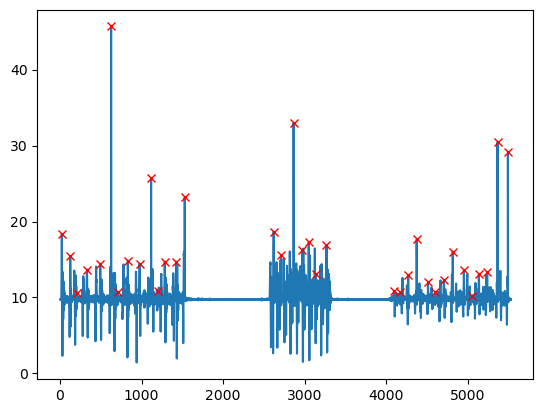

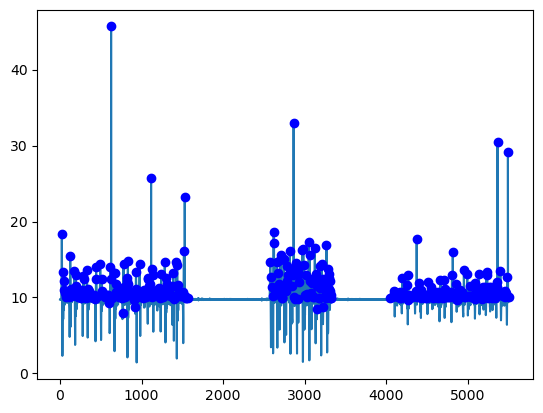

In [22]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.signal import find_peaks

signal = subject2ex1["acc_mag_u2"].to_numpy()
peaks, _ = find_peaks(signal, distance=80, prominence=0.6)
peaks2, _ = find_peaks(signal, prominence=0.3)
plt.plot(signal)
plt.plot(peaks, signal[peaks], "xr")
plt.show()

plt.plot(signal)
plt.plot(peaks2, signal[peaks2], "ob"); 

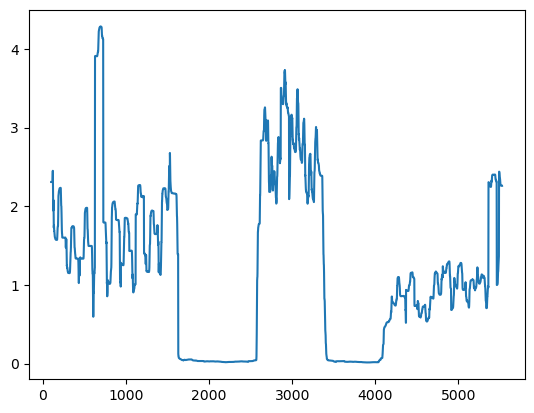

In [23]:
energy = pd.Series(signal).rolling(100).std()

plt.plot(energy)

In [45]:
print(subject2ex1[["acc_mag_u1", "acc_mag_u2"]].head(10))

       acc_mag_u1  acc_mag_u2
47395    9.814596    9.743088
47396    9.808314    9.777732
47397    9.809786    9.740462
47398    9.796164    9.761856
47399    9.800966    9.758739
47400    9.808085    9.766668
47401    9.801329    9.785645
47402    9.796360    9.782146
47403    9.820667    9.771933
47404    9.806169    9.744256
